In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

In [4]:
train_df=pd.read_csv("train_human_predict.csv")
test_df=pd.read_csv("test_human_predict.csv")

In [6]:
pd.set_option('display.max_rows', None)
train_df.isnull().sum()

tBodyAcc-mean()-X                       0
tBodyAcc-mean()-Y                       0
tBodyAcc-mean()-Z                       0
tBodyAcc-std()-X                        0
tBodyAcc-std()-Y                        0
tBodyAcc-std()-Z                        0
tBodyAcc-mad()-X                        0
tBodyAcc-mad()-Y                        0
tBodyAcc-mad()-Z                        0
tBodyAcc-max()-X                        0
tBodyAcc-max()-Y                        0
tBodyAcc-max()-Z                        0
tBodyAcc-min()-X                        0
tBodyAcc-min()-Y                        0
tBodyAcc-min()-Z                        0
tBodyAcc-sma()                          0
tBodyAcc-energy()-X                     0
tBodyAcc-energy()-Y                     0
tBodyAcc-energy()-Z                     0
tBodyAcc-iqr()-X                        0
tBodyAcc-iqr()-Y                        0
tBodyAcc-iqr()-Z                        0
tBodyAcc-entropy()-X                    0
tBodyAcc-entropy()-Y              

In [7]:
pd.set_option('display.max_rows', None)
test_df.isnull().sum()

tBodyAcc-mean()-X                       0
tBodyAcc-mean()-Y                       0
tBodyAcc-mean()-Z                       0
tBodyAcc-std()-X                        0
tBodyAcc-std()-Y                        0
tBodyAcc-std()-Z                        0
tBodyAcc-mad()-X                        0
tBodyAcc-mad()-Y                        0
tBodyAcc-mad()-Z                        0
tBodyAcc-max()-X                        0
tBodyAcc-max()-Y                        0
tBodyAcc-max()-Z                        0
tBodyAcc-min()-X                        0
tBodyAcc-min()-Y                        0
tBodyAcc-min()-Z                        0
tBodyAcc-sma()                          0
tBodyAcc-energy()-X                     0
tBodyAcc-energy()-Y                     0
tBodyAcc-energy()-Z                     0
tBodyAcc-iqr()-X                        0
tBodyAcc-iqr()-Y                        0
tBodyAcc-iqr()-Z                        0
tBodyAcc-entropy()-X                    0
tBodyAcc-entropy()-Y              

In [10]:
train_df["Activity"].unique() #gives the list of uniques values

array(['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [11]:
train_df["Activity"].nunique() #gives the number of uniques values

6

In [19]:
#Conver the string to numerical values
le=LabelEncoder()
train_df["Activity"]=le.fit_transform(train_df["Activity"])
test_df["Activity"]=le.transform(test_df["Activity"])

In [20]:
print(train_df["Activity"])
print("-----------------------------")
print(test_df["Activity"])

0       2
1       2
2       2
3       2
4       2
5       2
6       2
7       2
8       2
9       2
10      2
11      2
12      2
13      2
14      2
15      2
16      2
17      2
18      2
19      2
20      2
21      2
22      2
23      2
24      2
25      2
26      2
27      1
28      1
29      1
30      1
31      1
32      1
33      1
34      1
35      1
36      1
37      1
38      1
39      1
40      1
41      1
42      1
43      1
44      1
45      1
46      1
47      1
48      1
49      1
50      1
51      0
52      0
53      0
54      0
55      0
56      0
57      0
58      0
59      0
60      0
61      0
62      0
63      0
64      0
65      0
66      0
67      0
68      0
69      0
70      0
71      0
72      0
73      0
74      0
75      0
76      0
77      0
78      3
79      3
80      3
81      3
82      3
83      3
84      3
85      3
86      3
87      3
88      3
89      3
90      3
91      3
92      3
93      3
94      3
95      3
96      3
97      3
98      3
99      3


In [21]:
X_train=train_df.drop("Activity",axis=1)
y_train=train_df["Activity"]

X_test=test_df.drop("Activity",axis=1)
y_test=test_df["Activity"]

In [22]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [32]:
#Finding the best value of K using K tuning
accuracy=[]
precision=[]
recall=[]
for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_predict=knn.predict(X_test)

    accuracy.append(accuracy_score(y_test,y_predict))
    precision.append(precision_score(y_test,y_predict,average="macro"))
    recall.append(recall_score(y_test,y_predict,average="macro"))
print("Accuracy List:",accuracy)
print("Precision List:",precision)   
print("Recall List:",recall)

Accuracy List: [0.8547675602307431, 0.8537495758398371, 0.8741092636579573, 0.8798778418730913, 0.8842891075670173, 0.8887003732609433, 0.8897183576518494, 0.8937902952154734, 0.8941296233457754, 0.8944689514760774, 0.8880217170003394, 0.8937902952154734, 0.8937902952154734, 0.8897183576518494, 0.8907363420427553, 0.8903970139124533, 0.8873430607397353, 0.8910756701730573, 0.8866644044791313, 0.8917543264336614]
Precision List: [0.86147429853744, 0.8665650274515938, 0.8824942241243754, 0.8870065295859102, 0.8932834941335858, 0.8965300168847361, 0.899341358017436, 0.9026584724422672, 0.9031798771751477, 0.9030488190693059, 0.899286473751077, 0.9029171543291473, 0.9046499366930253, 0.8996925990098917, 0.9015369742070886, 0.9005992571248367, 0.8998338529883707, 0.9019756091487411, 0.8993641977022769, 0.9028259961845517]
Recall List: [0.8505101529669071, 0.8494438845390456, 0.8689216209903631, 0.8753883074433908, 0.8789879204339818, 0.8832721164032226, 0.8845339263884275, 0.888513981190663

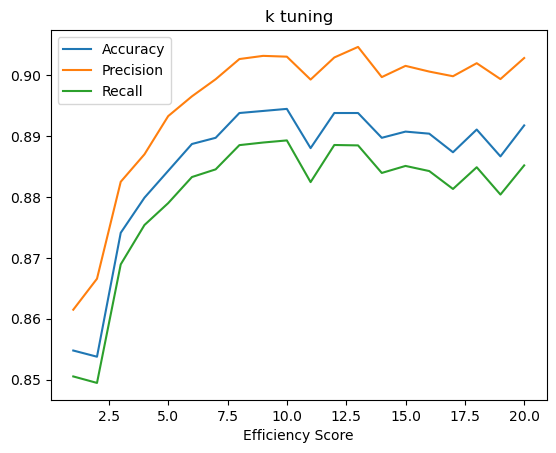

In [33]:
plt.plot(range(1,21),accuracy,label="Accuracy")
plt.plot(range(1,21),precision,label="Precision")
plt.plot(range(1,21),recall,label="Recall")
plt.xlabel("VALUE OF k")
plt.xlabel("Efficiency Score")
plt.title("k tuning")
plt.legend()
plt.show()

In [35]:
#K nearest neighbours
knn=KNeighborsClassifier(n_neighbors=8) # large K values gives underfitting curve and small values of K give overfitting curve
# we did not take 13 as the graph is zig-zag you should choose value which is stable according to the graph prrecision and recall
# must be balanced and accuracy must be high thus choos the values which is stable and peak dont go for peak poin but unstable

In [25]:
#In Regression problems use MSE and R2 score
#In Classification problems use Accuracy score,Confusion metrics,Precision,Recall and F-1 Score

In [37]:
knn.fit(X_train,y_train)
y_predict=knn.predict(X_test)
print("Accuracy Score",accuracy_score(y_test,y_predict))
print("Precision",precision_score(y_test,y_predict,average="macro"))
print("Recall",recall_score(y_test,y_predict,average="macro"))
print(confusion_matrix(y_test,y_predict)) # dimention depends on the no. of unique values in output coln.

Accuracy Score 0.8937902952154734
Precision 0.9026584724422672
Recall 0.8885139811906639
[[515  13   9   0   0   0]
 [  3 406  81   0   0   1]
 [  0  37 495   0   0   0]
 [  0   0   0 488   6   2]
 [  0   0   0  63 314  43]
 [  0   0   0  54   1 416]]
